In [ ]:
import pandas as pd
# import missingno as msno
# import seaborn as sns  
import matplotlib.pyplot as plt
from pandas.api.types import is_string_dtype
from pandas.api.types import is_numeric_dtype, is_datetime64_any_dtype


In [ ]:
data = pd.read_csv(r'loco_11_corr.tsv', sep = '\t')
data.head()

# Разведочный анализ и подготовка данных

В красной рамке вы видете пропуски данных
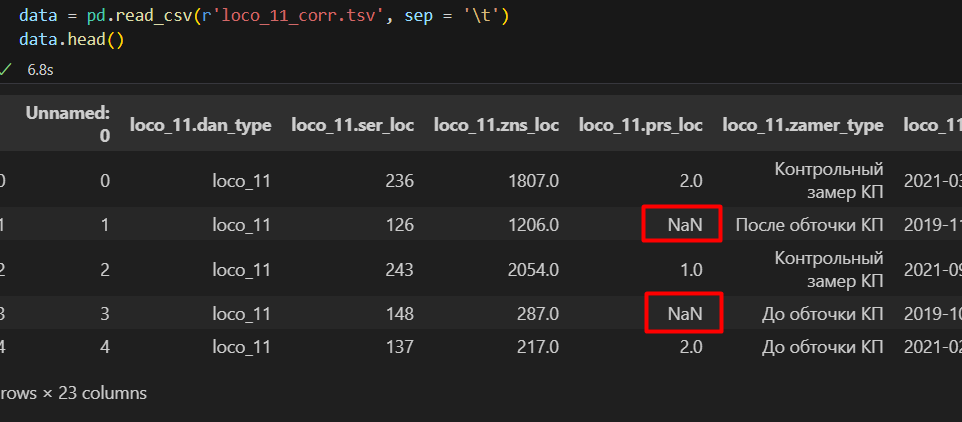

In [ ]:
# Облегчим себе жизнь. Удалим удалим loco_11. из назнавания столбцов
data.columns = data.columns.str.replace('loco_11.', '', regex=False)
data.head()

In [ ]:
#Проверка наличия пропусков в столбце
num_null_prs_loc = data['prs_loc'].isnull().sum()
print('количество пропусков по столбцу prs_loc: ', num_null_prs_loc)


In [ ]:
# Рассчитает долю записей, в которых есть пропуски по столбцу prs_loc
print('доля пропусков по столбцу prs_loc: ', num_null_prs_loc/len(data))

In [ ]:
data['prs_loc'].unique()

In [ ]:
data['ser_loc'].value_counts().sort_values().sum()

In [ ]:
# data['ser_loc'].groupby(data['prs_loc'])
# if data['prs_loc'].isnull()==1:
#     print (data['ser_loc'])
n2 = data[data['prs_loc'].isnull()==True]['ser_loc'].value_counts()
print(type(n2))

In [ ]:
data[data['prs_loc'].isnull()]

Упражнения на дом:
1. Узнаете что делает функция isnull()
2. Напиши код для вывода процента долей записей, в которых есть пропуски по полю prs_loc, округлите до 3его значащего символа

In [ ]:
# Посмотри как распределены пропуски по всем нашим столбцам
data.isnull().sum()

In [ ]:
# Отсортируем столбцы по наши столбцы по количество пропусков в них
# Посмотри как распределены пропуски по всем нашим столбцам
data.isnull().sum().sort_values(ascending=False)

In [ ]:
# Посмотрим доли пропусков
data.isnull().sum().sort_values(ascending=False)/len(data)
# Если мы удалим записи без

А вот теперь стало интересно, что это за столбцы такие, в которых столько пропусков. Лезем в метаданные - данные о данных

    ep_num_wp  - ID КП по данным АС ЭП
    prs_loc - номер секции           

Запускаем мышление: 
1. как курто было бы отслеживать историю каждой колесной пары. Есть идея - удалить все колеса, у которых нет ID, работать только с качественными данными
2. видимо это какой-то фантомный локомотив. Может быть стоит его удалить?

Это - наши первые гипотезы. И мы делаем такие выводы:
1. ep_num_wp - строки удалять нельзя, мы потеряем данные. "Убиваем" это столбец, он для нас не информативен.
2. prs_loc - о причинах пропусков нужно спросить у заказчика.

Ответ заказчика: пропуск - это значит односекциионный локомотив

In [ ]:
# Заменим пропуски по столбцу prs_loc
data['prs_loc'] = data['prs_loc'].fillna(0)
data.head()

In [ ]:
# Посмотрим как выглядят строки, по которым есть пропуски 
data[data['zamer_type'].isnull()==True]

In [ ]:
# Визуализируем пропуски в данных. Посмотрим насколько системны пропуски по столбцам
plt.figure(figsize=(12, 8))
sns.heatmap(data[data['zamer_type'].isnull()==True].isnull(), cmap='Blues')
plt.title('Пропуски в данных', fontsize=12)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

In [ ]:
# Второй метод визуализации пропущенных значений. 
msno.matrix(data[data['zamer_type'].isnull()==True])

In [ ]:
# Удалим столбец ep_num_wp
data = data.drop(columns = ['ep_num_wp'])
data.isnull().sum()/len(data)

In [ ]:
# Остались пропусков менее чем в % строк. Удалим эти строки
data = data.dropna()
data.isnull().sum()/len(data)

In [ ]:
# Проверим типы данных
data.info()

In [ ]:
# Проверка уникальности значений в столбцах
# Посмотрим вариативность значение. std - характеризует вариативность вокруг среднего значенич
data.describe().T['std'].sort_values()

In [ ]:
data.nunique().sort_values()

In [ ]:
var_stat = pd.concat([data.describe().T['std'].sort_values(), data.nunique().sort_values()], axis=1)
var_stat

In [ ]:
# Задание. Измените название столбцов var_stat так, чтобы название отражало содержимое. Добавьте в var_stat новые характеристики: 
#  размах - это разница между минимальным и максимальным значением. Подумайте почему есть пропуски в dan_type, zamer_type, repair_date, date_change

In [ ]:
# Задание. Сделайте вывод о том, какие столбцы надо удалить. Удалите их.

# Подготовка данных

In [ ]:
# Приведение к формату даты
data[['repair_date', 'date_change']] = data[['repair_date', 'date_change']].apply(pd.to_datetime, errors='coerce')
data.info()


In [ ]:
data.head()

In [ ]:
# Посмотрим вариантивность даты
data['repair_date'].value_counts()

In [ ]:
# Задание. Создайте новые столбцы: номер дня в году и месяц неисправности. Вот пример:
data['repair_week'] = data['repair_date'].dt.isocalendar().week #в старых версиях pandas можно не указывать стандарт iso а писать сразу dt.week
data['repair_week'].value_counts()

## Исследование аномалий

In [ ]:
# группировка данных. Сначала важно определить объект анализа.
# 
group_data = data.groupby(by = ['ser_loc', 'zns_loc', 'prs_loc','num_wp', 'zamer_type'])


In [ ]:
# Задание рассчитайте показатели колесной пары: max, min, средние и другие значения
